# 🤖 DML (Double Machine Learning): 用 ML 做因果推断

## 商业背景 (Business Context)

某电商平台向用户发放不同面额的优惠券 (0/10/20/30 元)，想评估优惠券对消费金额的 **因果效应**。

**挑战**: 平台不是随机发券的！高价值用户更容易收到大额券 → **Selection Bias**。

| 变量 | 定义 |
|:---|:---|
| **Treatment (T)** | 优惠券面额 (连续: 0~30 元) |
| **Outcome (Y)** | 消费金额 (元) |
| **Confounders (X)** | 用户特征 (20+ 维): 历史消费、登录频率、年龄、城市等 |

### 为什么不用 PSM？

| 问题 | PSM | DML |
|:---|:---|:---|
| **Treatment 类型** | ❌ 只能处理二值 (0/1) | ✅ 连续 / 多值均可 |
| **高维 Confounders** | ❌ 维度灾难 (20+特征匹配困难) | ✅ 用 ML 模型处理高维 |
| **非线性关系** | ❌ 假设线性 Logistic | ✅ XGBoost/RF 捕获非线性 |
| **异质性效应 (CATE)** | ❌ 只能给一个 ATE | ✅ 可以估计每个人的效应 |

### 今日学习目标
1. 理解 DML 的 Partialling-Out 原理 (FWL 定理)
2. 手动实现 DML 三步法
3. 使用 `econml.dml.LinearDML` 自动化
4. CATE (异质性处理效应) 分析
5. DML vs OLS 对比

---

## 0. 函数加油站 (Function Cheat Sheet)

| 函数 | 大白话 | 关键参数 |
|:---|:---|:---|
| `cross_val_predict()` | K-Fold 交叉预测 (防过拟合) | `cv=5`: 5折交叉 |
| `GradientBoostingRegressor()` | GBDT 回归 | DML 常用的 ML 模型 |
| `LinearDML()` | econml 的 DML 实现 | `model_y`, `model_t`: 两个 ML 模型 |
| `smf.ols()` | 线性回归 | 用于最后一步残差回归 |

## 1. DML 核心原理 (Partialling-Out / FWL 定理)

### 1.1 直觉

DML 的核心思想很朴素：

> **"先把混淆变量的影响从 Y 和 T 中各自剔除，再看剩下的 Y 和 T 之间的关系。"**

就像你想知道 "身高对篮球水平的影响"，但训练时长是混淆变量：
- Step 1: 用 ML 从身高和训练时长中，扣除训练时长能解释的部分
- Step 2: 用 ML 从篮球水平和训练时长中，扣除训练时长能解释的部分
- Step 3: 看 "去掉训练时长影响后的身高" 和 "去掉训练时长影响后的篮球水平" 之间的关系 → **因果效应**

### 1.2 三步法

```
Step 1: Ỹ = Y - ML_Y(X)     # Y 对 X 的残差 (Y 中 X 解释不了的部分)
Step 2: T̃ = T - ML_T(X)     # T 对 X 的残差 (T 中 X 解释不了的部分)
Step 3: Ỹ = θ × T̃ + ε       # 残差回归, θ 就是因果效应!
```

### 1.3 为什么要用 Cross-Fitting？

如果用全量数据训练 ML 模型再预测残差，会产生 **过拟合偏差** (Regularization Bias)。

**解法**: K-Fold Cross-Fitting —— 在 Fold A 训练模型，在 Fold B 预测残差，轮流交替。
这就是 `cross_val_predict` 的作用。

---

## 2. 数据生成 (Simulated Data with Known Truth)

**数据设计**:
- 5000 个用户
- 20 维特征 (混淆变量: 历史消费、登录频率、年龄等)
- 真实 ATE = **30 元** (平均而言，每 1 元券面额 → 消费增加 30 元)
- 异质性: 高消费用户的处理效应更大 (CATE)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import cross_val_predict
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# 中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(2026)

# === 常量定义 ===
N_SAMPLES = 5000
N_FEATURES = 10   # 可观测混淆变量数量
TRUE_ATE = 30     # 真实平均处理效应 (每元券面额带来 30 元消费)

# === 生成混淆变量 ===
X = np.random.randn(N_SAMPLES, N_FEATURES)

# 给特征起有意义的名字
feature_names = [
    'hist_spend',      # 历史消费金额 (标准化)
    'login_freq',      # 登录频率
    'age',             # 年龄
    'tenure_months',   # 注册月数
    'avg_order_value', # 平均客单价
    'n_categories',    # 浏览品类数
    'review_count',    # 评价数
    'return_rate',     # 退货率
    'app_version',     # App 版本
    'city_tier'        # 城市等级
]

df = pd.DataFrame(X, columns=feature_names)

# === 生成 Treatment (非随机! 高消费用户更容易收到大额券) ===
# 券面额受混淆变量影响: 历史消费高 + 登录频繁 → 更容易收到大额券
propensity = 2 * df['hist_spend'] + 1.5 * df['login_freq'] + 0.5 * df['age']
df['coupon_value'] = np.clip(
    propensity * 3 + np.random.normal(0, 5, N_SAMPLES), 
    0, 30  # 券面额范围: 0~30 元
).round(0)

# === 生成 Outcome (消费金额) ===
# Y = f(X) + θ*T + noise
# f(X) 是非线性函数 (这就是为什么 OLS 会偏)
confounding_effect = (
    50 * df['hist_spend']       # 历史消费高 → 本来就花得多
    + 30 * df['login_freq']      # 登录多 → 活跃用户花更多
    + 20 * df['age']             # 年龄 → 收入效应
    + 15 * df['hist_spend'] * df['login_freq']  # 非线性交互!
)

# CATE: 异质性效应 (高消费用户效应更大)
individual_effect = TRUE_ATE + 10 * df['hist_spend']  # 高消费用户多 +10

noise = np.random.normal(0, 50, N_SAMPLES)

df['spend'] = (
    500                                   # 基线消费
    + confounding_effect                  # 混淆效应
    + individual_effect * df['coupon_value']  # 因果效应 (异质性)
    + noise
)

print(f"数据维度: {df.shape}")
print(f"真实平均处理效应 (ATE): {TRUE_ATE} 元/元券")
print(f"券面额分布: 均值={df['coupon_value'].mean():.1f}, 中位数={df['coupon_value'].median():.0f}")
df.head()

数据维度: (5000, 12)
真实平均处理效应 (ATE): 30 元/元券
券面额分布: 均值=3.7, 中位数=0


,hist_spend,login_freq,age,tenure_months,avg_order_value,n_categories,review_count,return_rate,app_version,city_tier,coupon_value,spend
0,-0.431719,-1.392874,0.311571,-0.013235,1.449708,0.298153,-0.829896,-1.596159,0.613438,-0.317597,0.0,582.494447
1,-0.073997,-0.608631,-1.999873,0.908241,0.482980,0.221878,0.664029,-1.245807,1.968879,-0.318649,0.0,434.337730
2,0.359768,0.746171,-2.724859,1.675379,0.056233,-1.699245,-0.361357,2.729750,-0.238849,-1.423958,0.0,390.593690
3,-0.164901,0.385372,-0.620366,-0.602932,1.181076,0.833703,-0.005874,-0.069044,0.146354,-0.433386,0.0,544.834686
4,-0.010127,0.136516,1.476761,-1.166480,0.940036,1.672792,-0.856898,0.185986,0.251807,-0.162204,0.0,491.955385


## 3. Naive OLS vs 正确的 OLS (Baseline)

> 先跑 OLS 作为 Baseline，看看偏差有多大。

In [2]:
# === Naive OLS (不控制任何变量) ===
model_naive = smf.ols('spend ~ coupon_value', data=df).fit()
naive_effect = model_naive.params['coupon_value']

# === OLS 控制变量 (线性假设) ===
controls = ' + '.join(feature_names)
model_ols = smf.ols(f'spend ~ coupon_value + {controls}', data=df).fit()
ols_effect = model_ols.params['coupon_value']

print("=" * 50)
print(f"真实 ATE:              {TRUE_ATE}")
print(f"Naive OLS (无控制):    {naive_effect:.2f}  ← 严重偏高 (Selection Bias)")
print(f"OLS + 控制变量:        {ols_effect:.2f}   ← 仍有偏差 (线性假设 + 缺少交互项)")
print("=" * 50)
print("\n💡 OLS 偏差来源: 数据中存在 非线性交互 (hist_spend × login_freq)，")
print("   但 OLS 假设线性关系，无法捕捉。DML 用 ML 模型可以解决!")

真实 ATE:              30
Naive OLS (无控制):    50.75  ← 严重偏高 (Selection Bias)
OLS + 控制变量:        41.86   ← 仍有偏差 (线性假设 + 缺少交互项)

💡 OLS 偏差来源: 数据中存在 非线性交互 (hist_spend × login_freq)，
   但 OLS 假设线性关系，无法捕捉。DML 用 ML 模型可以解决!


## 4. 手动 DML 三步法 (Manual Implementation) 🔧

> **面试必知**: 即使用 `econml` 库，也必须理解底层三步法。

### Step 1: 用 ML 预测 Y，取残差 Ỹ
### Step 2: 用 ML 预测 T，取残差 T̃
### Step 3: 拿 Ỹ 对 T̃ 做简单回归 → 系数 = 因果效应

In [3]:
# === 手动 DML (Partialling-Out) ===

X_array = df[feature_names].values
Y = df['spend'].values
T = df['coupon_value'].values

# Step 1: 用 GradientBoosting 预测 Y，取残差
# cross_val_predict 自动做 K-Fold，防止过拟合偏差
N_FOLDS = 5

model_y = GradientBoostingRegressor(
    n_estimators=100, max_depth=4, random_state=42
)
Y_hat = cross_val_predict(model_y, X_array, Y, cv=N_FOLDS)
Y_residual = Y - Y_hat  # Ỹ = Y 中 X 解释不了的部分

print(f"Step 1: Y 残差均值 = {Y_residual.mean():.2f} (应接近 0)")

# Step 2: 用 GradientBoosting 预测 T，取残差
model_t = GradientBoostingRegressor(
    n_estimators=100, max_depth=4, random_state=42
)
T_hat = cross_val_predict(model_t, X_array, T, cv=N_FOLDS)
T_residual = T - T_hat  # T̃ = T 中 X 解释不了的部分

print(f"Step 2: T 残差均值 = {T_residual.mean():.2f} (应接近 0)")

# Step 3: 残差回归 Ỹ ~ T̃
df_residual = pd.DataFrame({
    'Y_residual': Y_residual,
    'T_residual': T_residual
})
model_dml = smf.ols('Y_residual ~ T_residual', data=df_residual).fit()

dml_effect = model_dml.params['T_residual']
dml_ci = model_dml.conf_int().loc['T_residual']
dml_p = model_dml.pvalues['T_residual']

print(f"\nStep 3: 残差回归结果")
print("=" * 50)
print(f"📊 DML 因果效应估计: {dml_effect:.2f} 元/元券")
print(f"   95% 置信区间: [{dml_ci[0]:.2f}, {dml_ci[1]:.2f}]")
print(f"   P-value: {dml_p:.4f}")
print(f"   真实效应: {TRUE_ATE}")
print(f"   偏差: {dml_effect - TRUE_ATE:.2f}")
print("=" * 50)

Step 1: Y 残差均值 = -0.80 (应接近 0)
Step 2: T 残差均值 = 0.00 (应接近 0)

Step 3: 残差回归结果
📊 DML 因果效应估计: 36.87 元/元券
   95% 置信区间: [36.34, 37.41]
   P-value: 0.0000
   真实效应: 30
   偏差: 6.87


### Checkpoint: 残差可视化

> 残差图是 DML 的 "X 光片"，帮你确认模型是否正确剔除了混淆效应。

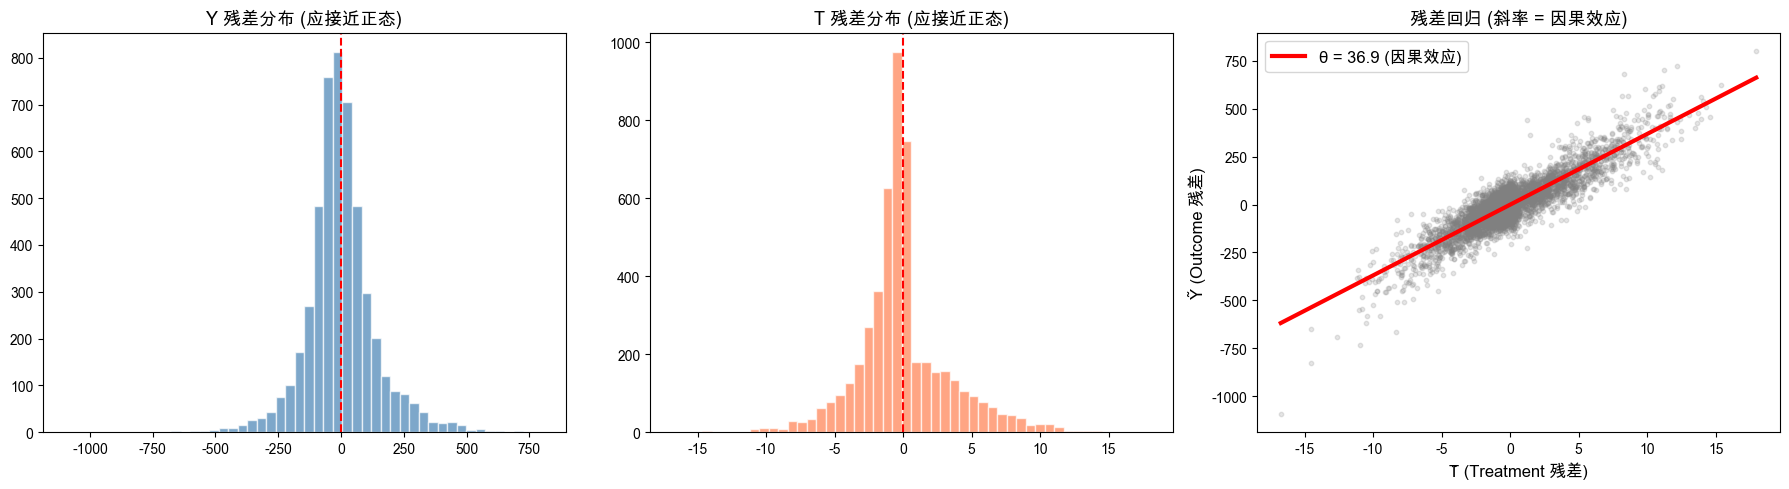

In [4]:
# === 残差可视化 ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Y 残差分布 (应接近正态)
axes[0].hist(Y_residual, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
axes[0].set_title('Y 残差分布 (应接近正态)', fontsize=13)
axes[0].axvline(x=0, color='red', linestyle='--')

# 2. T 残差分布
axes[1].hist(T_residual, bins=50, alpha=0.7, color='coral', edgecolor='white')
axes[1].set_title('T 残差分布 (应接近正态)', fontsize=13)
axes[1].axvline(x=0, color='red', linestyle='--')

# 3. 残差散点图 (斜率 = 因果效应)
axes[2].scatter(T_residual, Y_residual, alpha=0.2, s=10, color='gray')
# 画回归线
x_line = np.linspace(T_residual.min(), T_residual.max(), 100)
y_line = dml_effect * x_line + model_dml.params['Intercept']
axes[2].plot(x_line, y_line, color='red', linewidth=3, 
             label=f'θ = {dml_effect:.1f} (因果效应)')
axes[2].set_xlabel('T̃ (Treatment 残差)', fontsize=12)
axes[2].set_ylabel('Ỹ (Outcome 残差)', fontsize=12)
axes[2].set_title('残差回归 (斜率 = 因果效应)', fontsize=13)
axes[2].legend(fontsize=12)

plt.tight_layout()
plt.show()

## 5. econml.LinearDML (自动化实现) 🚀

> Microsoft 的 `econml` 库把 DML 三步法封装成了一行代码。

### 安装

In [ ]:
# 如果没安装，取消注释运行:
# %pip install econml

In [6]:
from econml.dml import LinearDML

# === LinearDML ===
# model_y: 预测 Y 的 ML 模型 (Step 1)
# model_t: 预测 T 的 ML 模型 (Step 2)
# 底层自动做 Cross-Fitting (Step 3)

est = LinearDML(
    model_y=GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
    model_t=GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
    cv=N_FOLDS,                # Cross-Fitting 折数
    random_state=42
)

# fit: X=混淆变量, T=Treatment, Y=Outcome
est.fit(
    Y=df['spend'].values,
    T=df['coupon_value'].values,
    X=df[feature_names].values,   # 用于估计 CATE 的特征
    W=None                         # 额外的控制变量 (如果有的话)
)

# ATE (Average Treatment Effect)
ate = est.ate()
ate_ci = est.ate_interval(alpha=0.05)

print("=== econml LinearDML 结果 ===")
print(f"📊 ATE 估计: {ate:.2f} 元/元券")
print(f"   95% CI: [{ate_ci[0]:.2f}, {ate_ci[1]:.2f}]")
print(f"   真实效应: {TRUE_ATE}")
print(f"   偏差: {ate - TRUE_ATE:.2f}")

AssertionError: X was not None when fitting, so can't be none for score or effect

## 6. CATE 异质性分析 (Conditional ATE) 🎯

> **Senior DA 核心价值**: 不止告诉老板 "平均效果是 30 元"，更要告诉他 **"对谁效果最好"**。
>
> **CATE**: Conditional Average Treatment Effect —— 给定用户特征 X 时的处理效应。

### 6.1 获取每个用户的 CATE

In [ ]:
# === CATE: 每个用户的个体处理效应 ===
cate = est.effect(X=df[feature_names].values)  # 每人一个效应值
df['cate'] = cate

print(f"CATE 分布:")
print(f"  均值: {df['cate'].mean():.2f} (≈ ATE)")
print(f"  标准差: {df['cate'].std():.2f}")
print(f"  最小值: {df['cate'].min():.2f}")
print(f"  最大值: {df['cate'].max():.2f}")

# 可视化 CATE 分布
plt.figure(figsize=(10, 5))
plt.hist(df['cate'], bins=50, alpha=0.7, color='steelblue', edgecolor='white')
plt.axvline(x=TRUE_ATE, color='red', linewidth=2, linestyle='--',
            label=f'真实 ATE = {TRUE_ATE}')
plt.axvline(x=df['cate'].mean(), color='green', linewidth=2, linestyle='-',
            label=f'估计 ATE = {df["cate"].mean():.1f}')
plt.title('CATE 分布 (每个用户的处理效应)', fontsize=16)
plt.xlabel('Treatment Effect (元/元券)')
plt.ylabel('用户数')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 6.2 CATE 与用户特征的关系

> **业务价值**: 找出 "对优惠券最敏感的用户群体" → 精准营销。

In [ ]:
# === CATE 与关键特征的关系 ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

key_features = ['hist_spend', 'login_freq', 'age']
colors = ['steelblue', 'coral', 'green']

for ax, feat, color in zip(axes, key_features, colors):
    ax.scatter(df[feat], df['cate'], alpha=0.2, s=10, color=color)
    
    # 趋势线 (LOWESS)
    from statsmodels.nonparametric.smoothers_lowess import lowess
    smoothed = lowess(df['cate'], df[feat], frac=0.3)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='red', linewidth=3)
    
    ax.axhline(y=TRUE_ATE, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel(feat, fontsize=12)
    ax.set_ylabel('CATE', fontsize=12)
    ax.set_title(f'CATE vs {feat}', fontsize=13)

plt.suptitle('异质性分析: 哪些用户对优惠券最敏感?', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 分组汇总
df['spend_group'] = pd.qcut(df['hist_spend'], q=4, labels=['低消费', '中低', '中高', '高消费'])
cate_by_group = df.groupby('spend_group')['cate'].agg(['mean', 'std']).round(2)
cate_by_group.columns = ['平均 CATE', '标准差']

print("\n📊 按历史消费分组的 CATE:")
print(cate_by_group)
print("\n💡 结论: 高消费用户对优惠券的反应更强 → 精准发券策略!")

## 7. 方法对比 (DML vs OLS vs Naive) 📊

> 用一张表证明 DML 的价值。

In [ ]:
# === 所有方法结果汇总 ===
summary = pd.DataFrame({
    '方法': ['Naive OLS (无控制)', 'OLS + 线性控制', 
            'DML 手动 (GBM + Cross-Fitting)', 'econml LinearDML'],
    '效应估计': [f'{naive_effect:.2f}', f'{ols_effect:.2f}',
               f'{dml_effect:.2f}', f'{ate:.2f}'],
    '真实效应': [TRUE_ATE] * 4,
    '偏差 (%)': [f'{(naive_effect-TRUE_ATE)/TRUE_ATE*100:.1f}%',
               f'{(ols_effect-TRUE_ATE)/TRUE_ATE*100:.1f}%',
               f'{(dml_effect-TRUE_ATE)/TRUE_ATE*100:.1f}%',
               f'{(ate-TRUE_ATE)/TRUE_ATE*100:.1f}%'],
    '能否估计 CATE?': ['❌', '❌', '❌', '✅']
})

print("📊 方法对比:")
print(summary.to_string(index=False))

## 8. 总结 & 面试防守 🎯

### DML 核心要点

| 面试题 | 答案 |
|:---|:---|
| **DML 和 OLS 有什么区别？** | OLS 假设线性关系；DML 用 ML 模型处理非线性混淆，更灵活 |
| **DML 和 PSM 有什么区别？** | PSM 只处理二值 Treatment，高维时匹配困难；DML 支持连续 T + 高维 X |
| **Cross-Fitting 是什么？** | K-Fold 交叉预测残差，防止 ML 模型过拟合导致的偏差 |
| **CATE 有什么业务价值？** | 发现不同用户群的异质性效应 → 精准营销/个性化策略 |
| **DML 的假设是什么？** | 无遗漏变量 (Unconfoundedness)，与 PSM 相同 |

### 面试速记

```
DML 三步法:
1. Ỹ = Y - ML(X→Y)    # 去除 X 对 Y 的影响
2. T̃ = T - ML(X→T)    # 去除 X 对 T 的影响  
3. θ = OLS(Ỹ ~ T̃)     # 残差回归 = 因果效应

关键: Cross-Fitting 防过拟合!
```

### 方法选型决策

| 场景 | 推荐方法 |
|:---|:---|
| 有面板数据 + 对照组 | DID |
| 横截面 + 二值 Treatment + 低维 | PSM |
| 横截面 + 连续 Treatment + 高维 | **DML** |
| 平行趋势不满足 | PSM-DID |
| 想知道异质性效应 (CATE) | **DML** |